In [1]:
import os
import random
import torch, torchvision
from torch import nn
from torchvision import datasets, transforms
#from torchvision.models import 
from torch.utils.data import DataLoader
import timm

from captum.attr import IntegratedGradients, NoiseTunnel
from captum.attr import visualization as viz

from collections import Counter
import gc
from time import sleep
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from IPython.display import display


#Utilities shared between models
import helpers as h

gc.collect()
torch.cuda.empty_cache()

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

/home/csuti/Development/Medical_Data_Processing/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using cuda device


# CoAtNet

## Config

In [2]:
#Config

modelName = "CoAtNet-2"
modelPath = f"Models/{modelName}.pth"
historyPath = f"Models/{modelName}_history.csv" #recorded stats during training
statePath = f"Models/{modelName}_state.pth"  #optimizer & current epoch

purge = False   #Start a new model from scratch
training = False  #Whether to train the model or just load it

#Paralell training examples 
BATCH_SIZE = 4   #GPU a limit
#CPU workers to load data to gpu
WORKERS = 8   #Ezt még talán lehet növelni

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.05


## Loading / initializing resources

### DataLoader and dataset parameters

In [3]:
train_loader = h.GetTrainingDataloader(batch_size=BATCH_SIZE, num_workers=WORKERS)
val_loader = h.GetValDataloader(batch_size=BATCH_SIZE, num_workers=WORKERS)
test_loader = h.GetTestDataloader(batch_size=BATCH_SIZE, num_workers=WORKERS)

ClassNames = train_loader.dataset.classes
numClasses = len(ClassNames)

print(f"Classes: {ClassNames}")
print(f"Number of classes: {numClasses}")

Classes: ['Actinic keratoses', 'Basal cell carcinoma', 'Benign keratosis-like lesions', 'Dermatofibroma', 'Melanocytic nevi', 'Melanoma', 'Squamous cell carcinoma', 'Vascular lesions']
Number of classes: 8


In [4]:
#Deriving Inverse frequency of classes to balance rare classes
totalSamples = len(train_loader.dataset) + len(test_loader.dataset) + len(val_loader.dataset)

samplesPerClass = Counter(train_loader.dataset.targets) 
#samplesPerClass.update(Counter(test_loader.dataset.targets))
#samplesPerClass.update(Counter(val_loader.dataset.targets))

inverseFrequencies = [ totalSamples/(numClasses * samplesPerClass[i]) for i in range(numClasses) ]
#freqvInv = [3.652, 0.953, 1.207, 13.248, 0.246, 0.700, 5.042, 12.515]  #from excel

print(totalSamples)
print(inverseFrequencies)

25331
[4.5690836940836945, 1.1912622272385252, 1.5085159599809432, 16.577879581151834, 0.30741504854368934, 0.8754147083218137, 6.307519920318725, 15.675123762376238]


### Model

In [5]:
#Model definition
model = timm.create_model(
    "coatnet_2_rw_224",   # <- first parameter
    pretrained=True,    #On imageNet
    num_classes=numClasses
)

### Loss function and optimizer

In [6]:
#LossFN and Optimizer
#criterion = nn.CrossEntropyLoss()
criterion = nn.CrossEntropyLoss(weight=torch.tensor(inverseFrequencies))
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

### Loading if available

In [7]:
#Loading or initializing model and statistics

epochs_done = 0
history = None

if not purge and os.path.exists(modelPath):
    model.load_state_dict(torch.load(modelPath))    #this loads latest model, not bestVal
    state = torch.load(statePath)
    optimizer.load_state_dict(state["optimizer"])
    epochs_done = state["epoch"]
    #load recorded stats too
    history = pd.read_csv(historyPath)
    print("Loaded last state")


Loaded last state


## Training

In [8]:
model = model.to(device)
criterion = criterion.to(device)

In [9]:
#Training config (=epoch overwrites)
#0 = off, priority: stopAt > maxOW
stopAt = 20
maxEpochOW = 0

#stopAt = 10    #stop at specific epoch
epochs = h.MAX_EPOCHS
if maxEpochOW: epochs = maxEpochOW
if stopAt: epochs = stopAt

if training:
    bestTrainAcc = 0.0
    bestValAcc = 0.0
    if history is not None and len(history) > 0:
        bestTrainAcc = history["train_acc"].max()
        bestValAcc = history["val_acc"].max()

    
    for epoch in range(epochs_done, epochs):
        print(f"Epoch {epoch+1}/{epochs} \t| ", end="")
        #Executing training and validation
        #train_loss, train_acc = 0,0
        train_loss, train_acc = h.trainingEpoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, CM = h.validate(model, val_loader, criterion, device)

        print(
            f"train loss: {train_loss:.4f}, train acc: {train_acc:.4f} | "
            f"val loss: {val_loss:.4f}, val acc: {val_acc:.4f}"
        )
        epochs_done += 1

        #Recording statistics
        sampleRow = {
            "epoch": epoch+1, "train_loss": train_loss, "train_acc": train_acc, "val_loss": val_loss, "val_acc": val_acc
        }
        sampleRow.update(h.FlattenCM(CM))
        if history is None:
            history = pd.DataFrame(columns=sampleRow.keys())
        history.loc[len(history)] = sampleRow

        #Saving snapshot
        torch.save(model.state_dict(), modelPath)
        torch.save({
                "epoch": epoch+1,
                "optimizer": optimizer.state_dict()
            }, statePath)        
        history.to_csv(historyPath, index=False)

        #saving best model
        if val_acc > bestValAcc:
            bestValAcc = val_acc
            torch.save(model.state_dict(), f"Models/{modelName}_bestVal.pth")
        
        if epoch == epochs-1: break
        sleep(90) #Let GPU cool a little

else:
    print("Already trained")

display(history)

Already trained


,epoch,train_loss,train_acc,val_loss,val_acc,cm_true_Actinic keratoses_pred_Actinic keratoses,cm_true_Basal cell carcinoma_pred_Actinic keratoses,cm_true_Benign keratosis-like lesions_pred_Actinic keratoses,cm_true_Dermatofibroma_pred_Actinic keratoses,cm_true_Melanocytic nevi_pred_Actinic keratoses,...,cm_true_Squamous cell carcinoma_pred_Squamous cell carcinoma,cm_true_Vascular lesions_pred_Squamous cell carcinoma,cm_true_Actinic keratoses_pred_Vascular lesions,cm_true_Basal cell carcinoma_pred_Vascular lesions,cm_true_Benign keratosis-like lesions_pred_Vascular lesions,cm_true_Dermatofibroma_pred_Vascular lesions,cm_true_Melanocytic nevi_pred_Vascular lesions,cm_true_Melanoma_pred_Vascular lesions,cm_true_Squamous cell carcinoma_pred_Vascular lesions,cm_true_Vascular lesions_pred_Vascular lesions
0,1,1.664121,0.502270,1.107308,0.612100,12,20,3,0,0,...,0,0,0,0,1,0,6,2,0,8
1,2,1.453414,0.567960,1.117241,0.584816,67,154,45,3,48,...,0,0,0,2,1,0,21,0,0,18
2,3,1.358079,0.593327,1.070654,0.615263,59,77,37,2,12,...,2,0,0,3,3,0,19,2,0,22
3,4,1.293459,0.610947,0.963729,0.649664,42,49,22,0,2,...,9,0,0,11,6,0,32,11,3,24
4,5,1.259686,0.618744,1.066861,0.626730,18,14,8,1,2,...,0,0,4,33,10,7,44,21,8,23
5,6,1.211224,0.630194,0.931278,0.659549,8,6,4,0,0,...,9,0,0,3,2,0,16,1,0,18
6,7,1.182497,0.640065,0.983888,0.653223,31,16,28,0,3,...,7,0,0,9,4,0,27,10,1,24
7,8,1.143454,0.645297,0.987756,0.634243,56,50,27,4,20,...,7,0,0,11,7,1,21,16,1,23
8,9,1.782222,0.441664,1.594527,0.392250,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,10,1.658782,0.511894,1.239468,0.578094,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
#latest CM
CM = h.ParseCM(history.iloc[-1][5:])
#display(history)
display(CM)

,Actinic keratoses,Basal cell carcinoma,Benign keratosis-like lesions,Dermatofibroma,Melanocytic nevi,Melanoma,Squamous cell carcinoma,Vascular lesions
Actinic keratoses,39,24,22,1,9,9,19,0
Basal cell carcinoma,24,265,29,0,44,24,20,0
Benign keratosis-like lesions,9,8,102,2,28,26,5,0
Dermatofibroma,1,4,5,18,8,4,2,0
Melanocytic nevi,2,12,56,2,1021,99,6,3
Melanoma,9,15,45,0,171,288,6,1
Squamous cell carcinoma,2,0,1,0,0,1,4,0
Vascular lesions,0,4,2,0,6,1,0,21


## Progress trough training

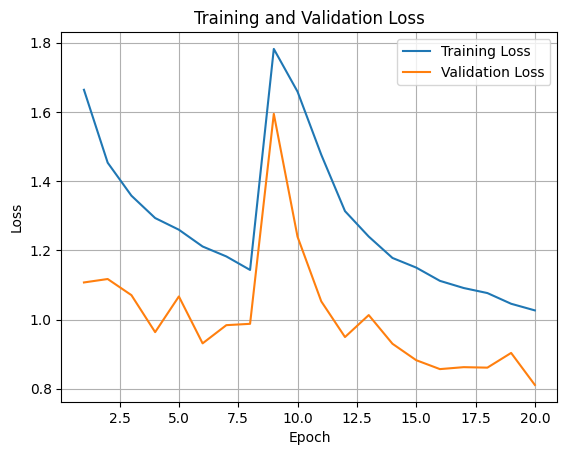

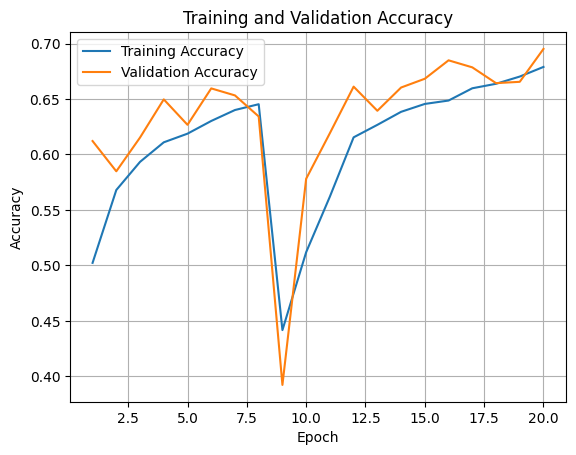

In [11]:
plt.figure()
plt.plot(history["epoch"], history["train_loss"], label="Training Loss")
plt.plot(history["epoch"], history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.savefig(f"Models/{modelName}_loss")
plt.show()

plt.figure()
plt.plot(history["epoch"], history["train_acc"], label="Training Accuracy")
plt.plot(history["epoch"], history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()
plt.savefig(f"Models/{modelName}_acc")
plt.show()

## Trying out trained model

In [12]:
#Testing should be done on best performing model

mpath = f"Models/{modelName}.pth" #latest model
mpath = f"Models/{modelName}_bestVal.pth" #with best validation

model.load_state_dict(torch.load(mpath))

<All keys matched successfully>

### Evaluate on test set

In [13]:
model = model.to(device)

test_loss, test_acc, TEST_CM = h.validate(model, test_loader, criterion, device)

print(f"test loss: {test_loss:.4f}, test acc: {test_acc:.4f}")

test loss: 0.8432, test acc: 0.6890


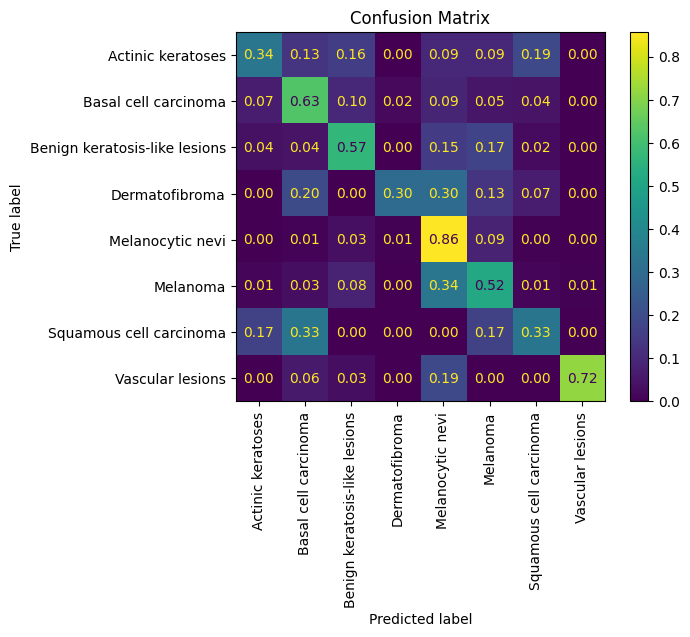

In [14]:
TEST_CM = TEST_CM.apply(pd.to_numeric)

cm_norm = TEST_CM.div(TEST_CM.sum(axis=1), axis=0)

disp = ConfusionMatrixDisplay(
    display_labels=cm_norm.index,
    confusion_matrix=cm_norm.values
)


disp.plot(values_format=".2f")
plt.title("Confusion Matrix")
plt.xticks(rotation=90)
plt.show()


### Deriving per class metrics

In [15]:
metrics = {}

for className in TEST_CM.index:
    TP, FN, FP, TN = h.PredictionsPerClass(TEST_CM, className)
    accuracy, precision, recall, f1 = h.ClassMetrics(TP, FN, FP, TN)
    metrics[className] = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }
metrics = pd.DataFrame(metrics).T
display(metrics)

,accuracy,precision,recall,f1
Actinic keratoses,0.950394,0.336207,0.443182,0.382353
Basal cell carcinoma,0.911417,0.625581,0.807808,0.705111
Benign keratosis-like lesions,0.907480,0.568627,0.441065,0.496788
Dermatofibroma,0.985433,0.300000,0.360000,0.327273
Melanocytic nevi,0.825591,0.857143,0.787267,0.820720
Melanoma,0.829134,0.517824,0.609272,0.559838
Squamous cell carcinoma,0.973228,0.333333,0.062500,0.105263
Vascular lesions,0.995276,0.718750,0.884615,0.793103


### Inspecting with captum

Examining what features are relevant

/home/csuti/Development/Medical_Data_Processing/venv/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 10 equal to the number of examples.
  warnings.warn(


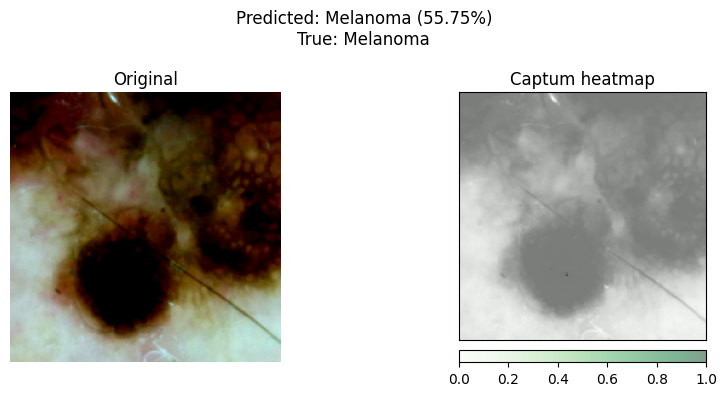

/home/csuti/Development/Medical_Data_Processing/venv/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 10 equal to the number of examples.
  warnings.warn(


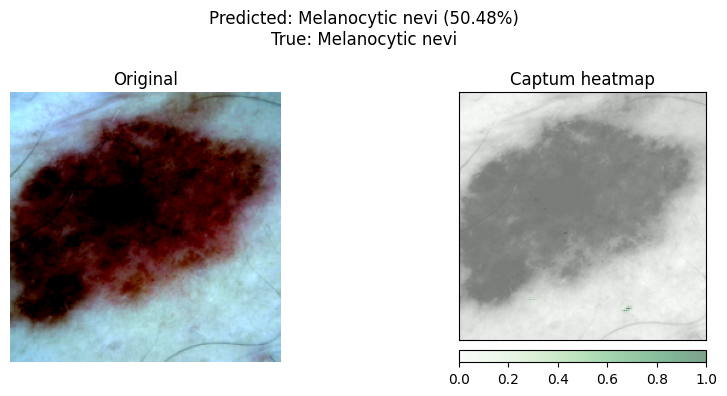

/home/csuti/Development/Medical_Data_Processing/venv/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 10 equal to the number of examples.
  warnings.warn(


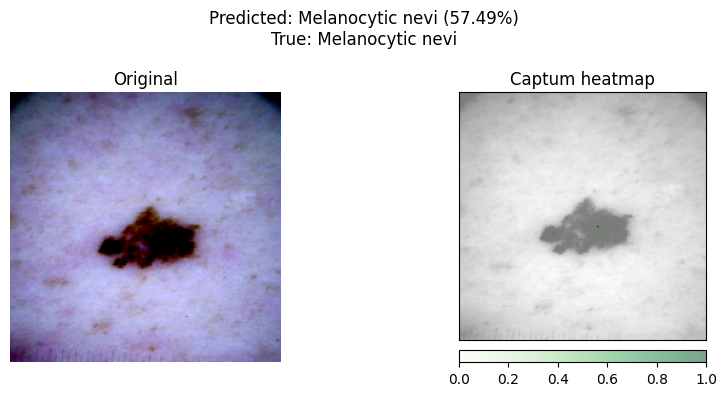

/home/csuti/Development/Medical_Data_Processing/venv/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 10 equal to the number of examples.
  warnings.warn(


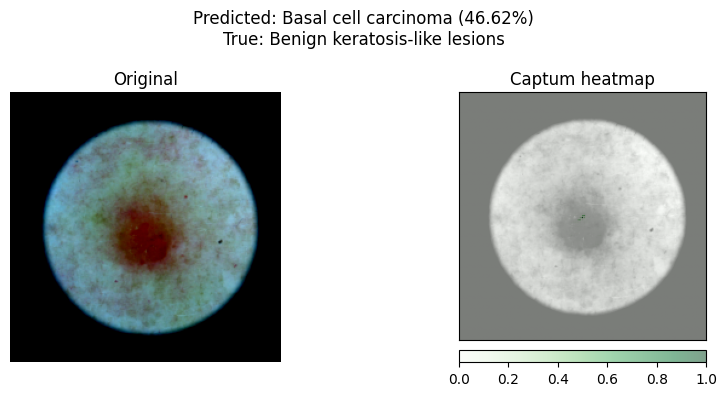

/home/csuti/Development/Medical_Data_Processing/venv/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 10 equal to the number of examples.
  warnings.warn(


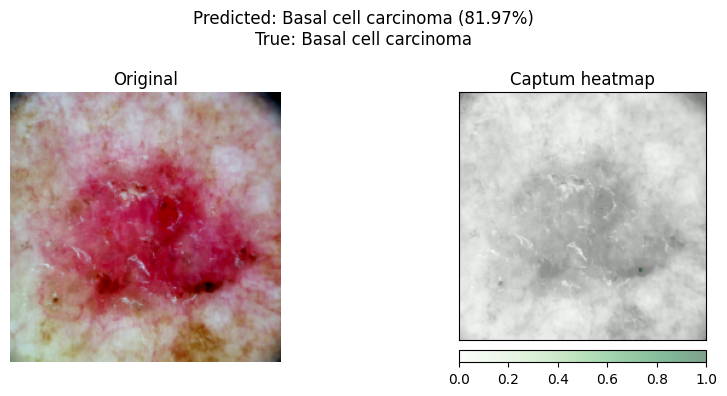

/home/csuti/Development/Medical_Data_Processing/venv/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 10 equal to the number of examples.
  warnings.warn(


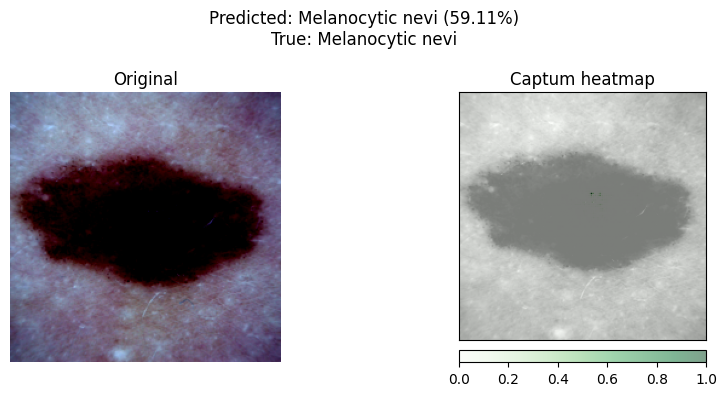

/home/csuti/Development/Medical_Data_Processing/venv/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 10 equal to the number of examples.
  warnings.warn(


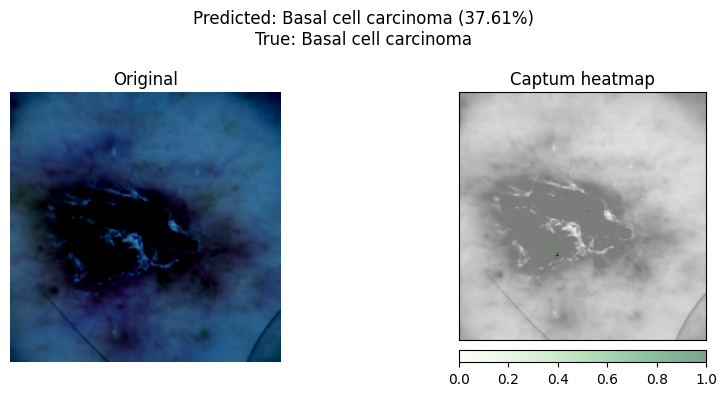

/home/csuti/Development/Medical_Data_Processing/venv/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 10 equal to the number of examples.
  warnings.warn(


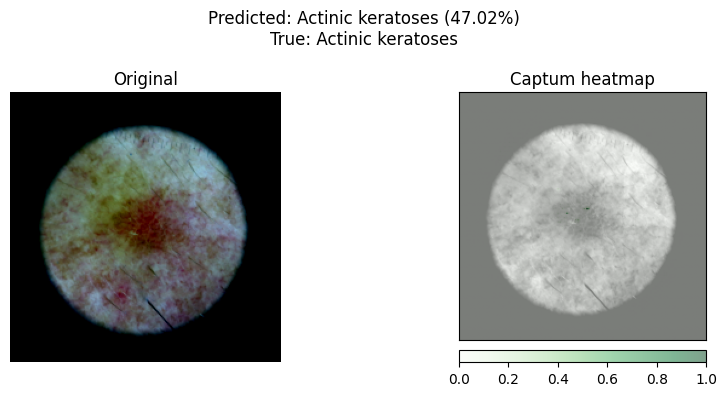

/home/csuti/Development/Medical_Data_Processing/venv/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 10 equal to the number of examples.
  warnings.warn(


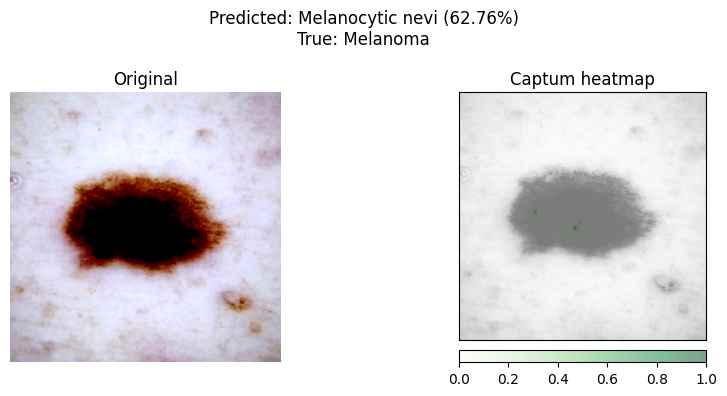

/home/csuti/Development/Medical_Data_Processing/venv/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 10 equal to the number of examples.
  warnings.warn(


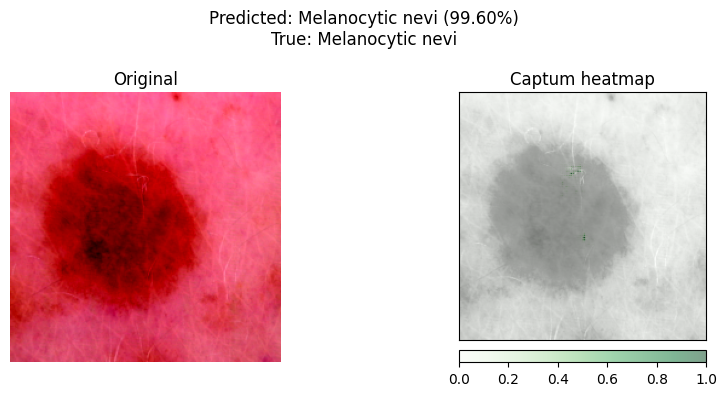

/home/csuti/Development/Medical_Data_Processing/venv/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 10 equal to the number of examples.
  warnings.warn(


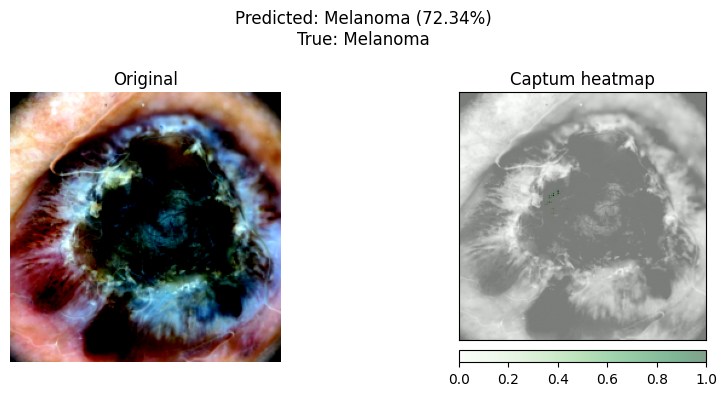

/home/csuti/Development/Medical_Data_Processing/venv/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 10 equal to the number of examples.
  warnings.warn(


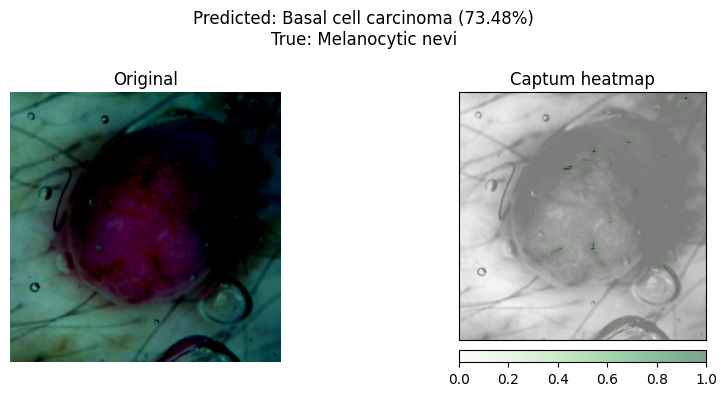

/home/csuti/Development/Medical_Data_Processing/venv/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 10 equal to the number of examples.
  warnings.warn(


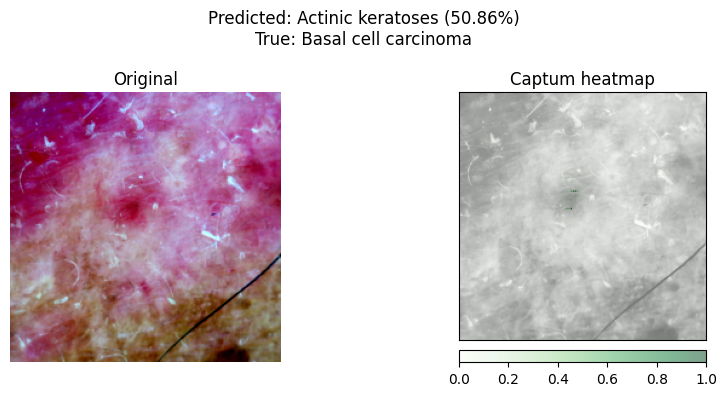

/home/csuti/Development/Medical_Data_Processing/venv/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 10 equal to the number of examples.
  warnings.warn(


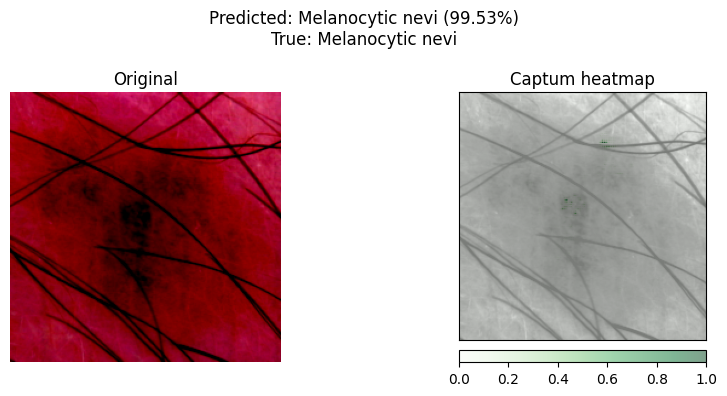

/home/csuti/Development/Medical_Data_Processing/venv/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 10 equal to the number of examples.
  warnings.warn(


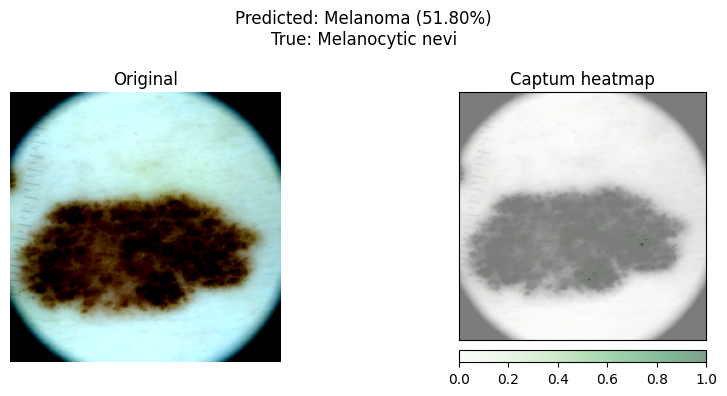

/home/csuti/Development/Medical_Data_Processing/venv/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 10 equal to the number of examples.
  warnings.warn(


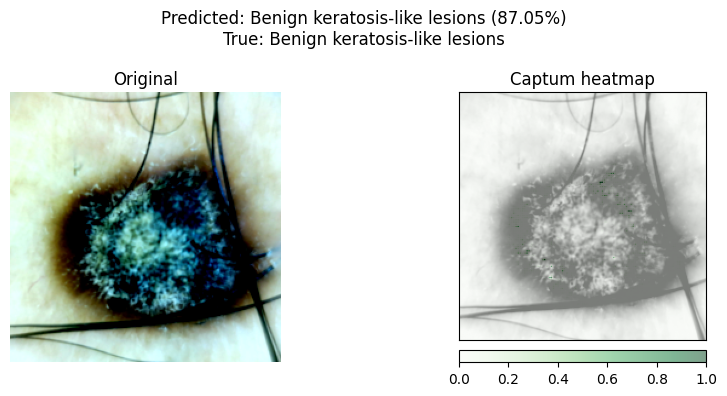

/home/csuti/Development/Medical_Data_Processing/venv/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 10 equal to the number of examples.
  warnings.warn(


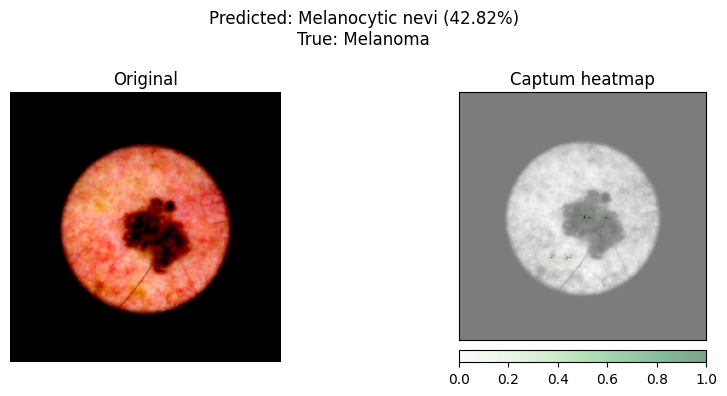

/home/csuti/Development/Medical_Data_Processing/venv/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 10 equal to the number of examples.
  warnings.warn(


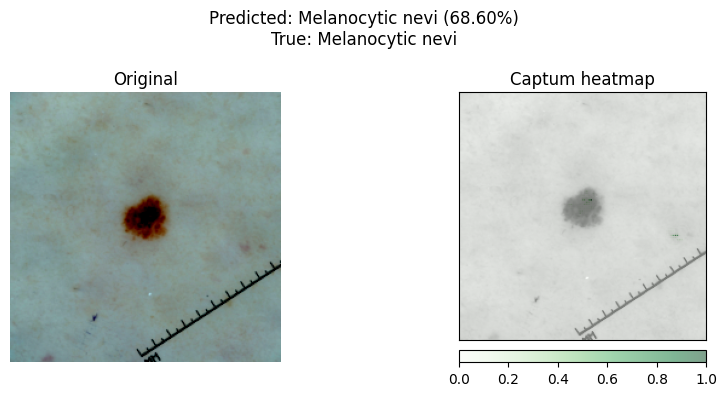

/home/csuti/Development/Medical_Data_Processing/venv/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 10 equal to the number of examples.
  warnings.warn(


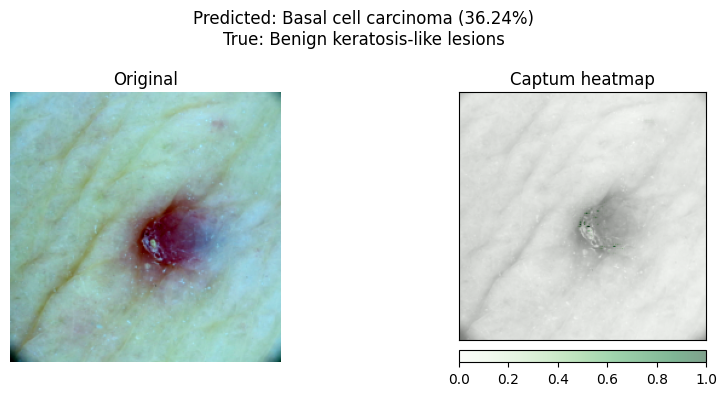

/home/csuti/Development/Medical_Data_Processing/venv/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 10 equal to the number of examples.
  warnings.warn(


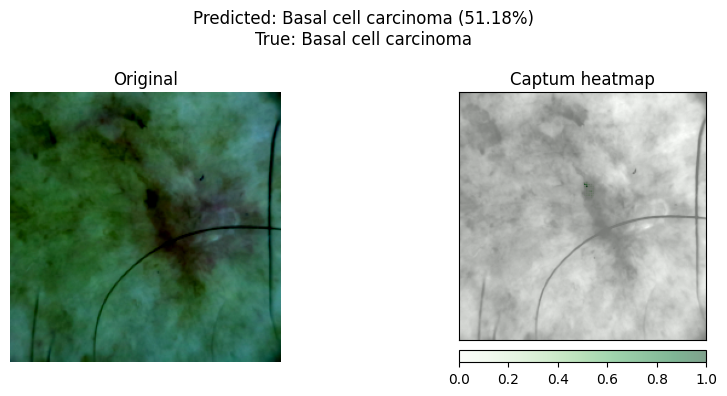

/home/csuti/Development/Medical_Data_Processing/venv/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 10 equal to the number of examples.
  warnings.warn(


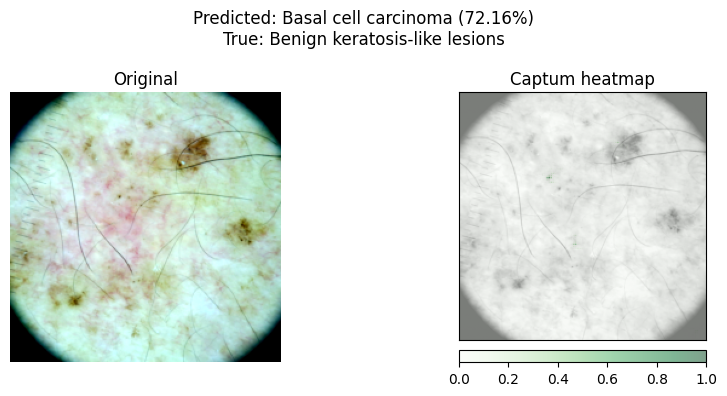

/home/csuti/Development/Medical_Data_Processing/venv/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 10 equal to the number of examples.
  warnings.warn(


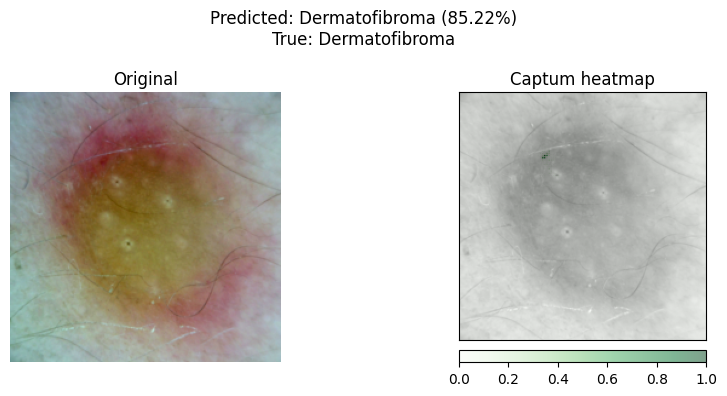

/home/csuti/Development/Medical_Data_Processing/venv/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 10 equal to the number of examples.
  warnings.warn(


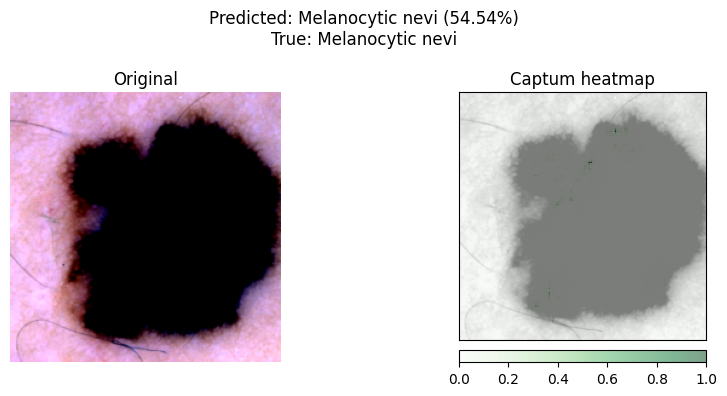

/home/csuti/Development/Medical_Data_Processing/venv/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 10 equal to the number of examples.
  warnings.warn(


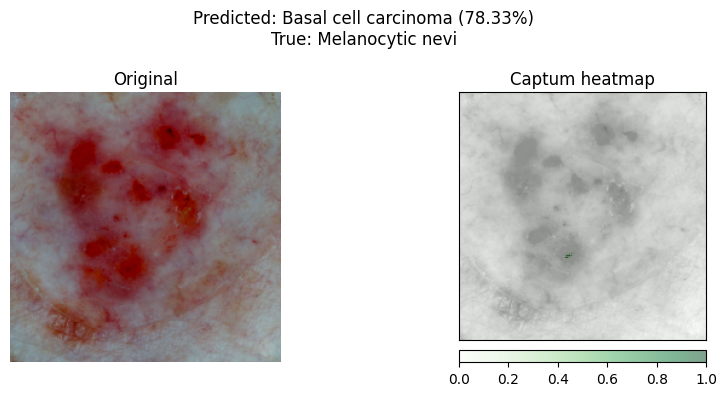

/home/csuti/Development/Medical_Data_Processing/venv/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 10 equal to the number of examples.
  warnings.warn(


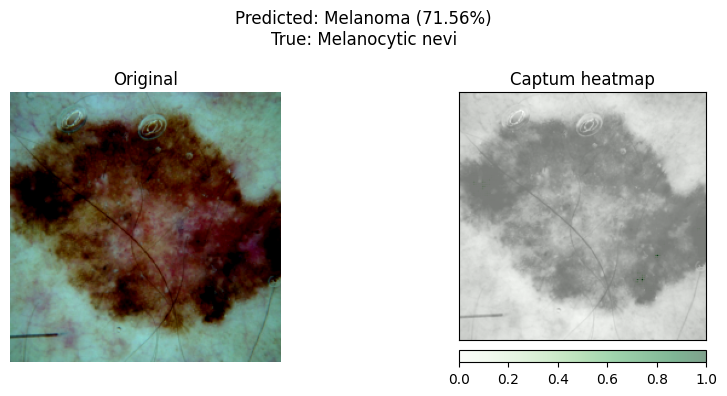

/home/csuti/Development/Medical_Data_Processing/venv/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 10 equal to the number of examples.
  warnings.warn(


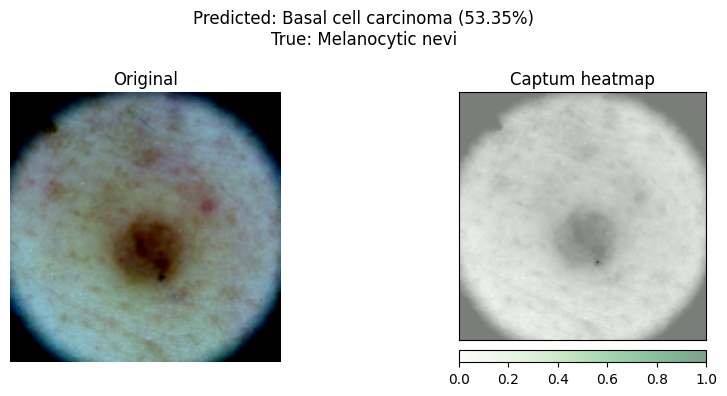

/home/csuti/Development/Medical_Data_Processing/venv/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 10 equal to the number of examples.
  warnings.warn(


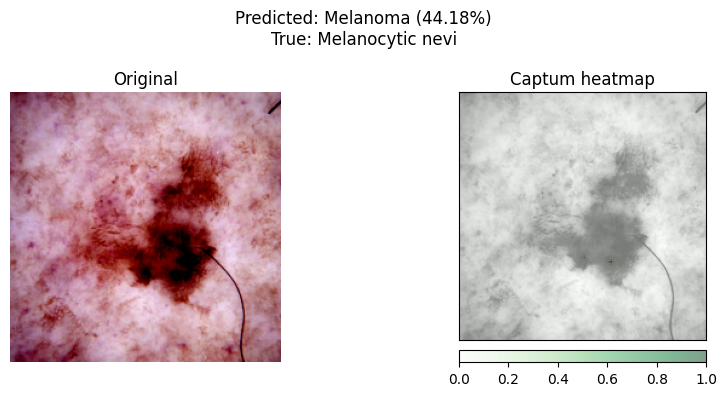

/home/csuti/Development/Medical_Data_Processing/venv/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 10 equal to the number of examples.
  warnings.warn(


KeyboardInterrupt: 

In [23]:
model.eval()

N_SAMPLES = 100
NT_SAMPLES = 10
INTERNAL_BATCH_SIZE = 1

random_indices = random.sample(range(len(test_loader.dataset)), N_SAMPLES)

ig = IntegratedGradients(model)
nt = NoiseTunnel(ig)

mean = torch.tensor(h.MEAN).view(3, 1, 1)
std = torch.tensor(h.STD).view(3, 1, 1)

for sample_idx in random_indices:
    torch.cuda.empty_cache()
    gc.collect()

    img, label = test_loader.dataset[sample_idx]

    input_img = img.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(input_img)
        probs = torch.softmax(logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()
        confidence = probs[0, pred].item()

    attributions = nt.attribute(
        input_img,
        target=pred,
        baselines=torch.zeros_like(input_img),
        nt_type="smoothgrad_sq",
        nt_samples=NT_SAMPLES,
        stdevs=0.02,
        internal_batch_size=INTERNAL_BATCH_SIZE,
    )

    img_vis = img.cpu() * mean + std
    img_vis = img_vis.clamp(0, 1)

    img_np = img_vis.permute(1, 2, 0).numpy()
    attr_np = attributions[0].detach().cpu().permute(1, 2, 0).numpy()

    true_label = ClassNames[label]
    pred_label = ClassNames[pred]

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))

    axes[0].imshow(img_np)
    axes[0].axis("off")
    axes[0].set_title("Original")

    viz.visualize_image_attr(
        attr_np,
        img_np,
        method="blended_heat_map",
        sign="positive",
        show_colorbar=True,
        plt_fig_axis=(fig, axes[1]),
        use_pyplot=False,
    )
    axes[1].set_title("Captum heatmap")

    fig.suptitle(
        f"Predicted: {pred_label} ({confidence:.2%})\n"
        f"True: {true_label}",
        fontsize=12,
    )

    plt.tight_layout()
    plt.show()

    del input_img, logits, probs, attributions
    torch.cuda.empty_cache()